# Classification Trees - Aquatic Macroinvertebrate Prediction

Decision-tree classifiers for the presence/absence of *Plecoptera: Perlidae* and *Trichoptera: Helicopsychidae* in the Cali River, using seven physicochemical predictors. Models are validated with a held-out test split plus stratified k-fold cross-validation on the training set.

## Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import cross_val_predict, train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

file_path = "../../data/DB - Macroinvertebrados.xlsx"
df = pd.read_excel(file_path)
df.columns = df.columns.str.strip()
df

,COT,DBO5,DBOU,DBO5s,DQO,Dureza,Fósforo,Fosfatos,Hierro,Magnesio,...,pH,Conductividad,OD,Temperatura,Coliformes,Profundidad,Velocidad,Caudal,Perlidae,Trichoptera
0,1.69,2,4,2,10.00,35.5,0.114,0.015,0.236,3.530,...,7.14,80,6.30,15.00,1012,0.44,0.55,1.39,1,0
1,5.24,7,9,5,14.79,124.0,1.640,0.758,6.680,17.400,...,7.40,469,4.33,25.86,11199,0.29,0.52,1.33,0,0
2,2.80,2,3,2,10.00,43.9,0.162,0.155,5.100,2.920,...,7.30,150,5.92,17.00,41,0.32,0.45,0.80,1,1
3,7.92,3,4,2,13.71,113.0,0.050,0.150,0.600,11.800,...,7.92,371,6.82,22.87,9804,0.33,0.71,0.92,0,0
4,12.20,8,10,7,10.00,46.4,0.580,0.150,0.233,3.920,...,7.38,110,6.50,18.40,24196,0.54,0.42,1.69,0,0
5,11.00,2,5,2,10.00,49.4,0.149,0.191,0.831,4.740,...,6.89,115,7.69,20.30,6867,0.36,0.32,1.59,0,0
6,4.33,35,26,15,70.60,108.0,1.500,1.080,0.195,0.378,...,6.94,300,5.05,25.23,19863,0.34,0.66,0.97,0,0
7,7.38,14,35,12,88.50,216.0,0.256,0.221,17.500,24.600,...,7.15,500,3.20,29.30,24196,0.49,0.76,1.50,0,0
8,7.20,2,3,2,10.00,47.5,0.443,0.221,0.100,5.540,...,8.16,112,5.90,18.62,676,0.46,0.42,0.87,0,0
9,3.04,2,3,2,10.00,98.4,0.050,0.150,0.411,11.400,...,7.90,294,7.01,19.94,2613,0.38,0.82,0.83,0,1


## Predictor Selection

Seven physicochemical predictors are used. English labels are kept for plotting.

In [2]:
feature_cols = ['COT', 'DBO5', 'Dureza', 'Magnesio', 'Turbiedad', 'OD', 'Caudal']
feature_names_en = ['TOC', 'BOD5', 'Hardness', 'Magnesium', 'Turbidity', 'DO', 'Flowrate']

## Model Definition & Evaluation

### Perlidae - tree with 7 predictors (depth 3)

A depth-3 tree was preferred on ecological grounds. Calibration metrics come from `cross_val_predict` with stratified k-fold on the training set; validation metrics come from the held-out test split.

In [3]:
X = df[feature_cols]
y = df['Perlidae']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

clf_perlidae = DecisionTreeClassifier(max_depth=3, random_state=1)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=1)

y_train_pred = cross_val_predict(clf_perlidae, X_train, y_train, cv=cv)
clf_perlidae.fit(X_train, y_train)
y_test_pred = clf_perlidae.predict(X_test)

print("Confusion matrix - calibration:")
print(confusion_matrix(y_train, y_train_pred))
print("\nClassification report - calibration:")
print(classification_report(y_train, y_train_pred))

print("Confusion matrix - validation:")
print(confusion_matrix(y_test, y_test_pred))
print("\nClassification report - validation:")
print(classification_report(y_test, y_test_pred))

Confusion matrix - calibration:
[[6 2]
 [2 2]]

Classification report - calibration:
              precision    recall  f1-score   support

           0       0.75      0.75      0.75         8
           1       0.50      0.50      0.50         4

    accuracy                           0.67        12
   macro avg       0.62      0.62      0.62        12
weighted avg       0.67      0.67      0.67        12

Confusion matrix - validation:
[[4 0]
 [1 1]]

Classification report - validation:
              precision    recall  f1-score   support

           0       0.80      1.00      0.89         4
           1       1.00      0.50      0.67         2

    accuracy                           0.83         6
   macro avg       0.90      0.75      0.78         6
weighted avg       0.87      0.83      0.81         6



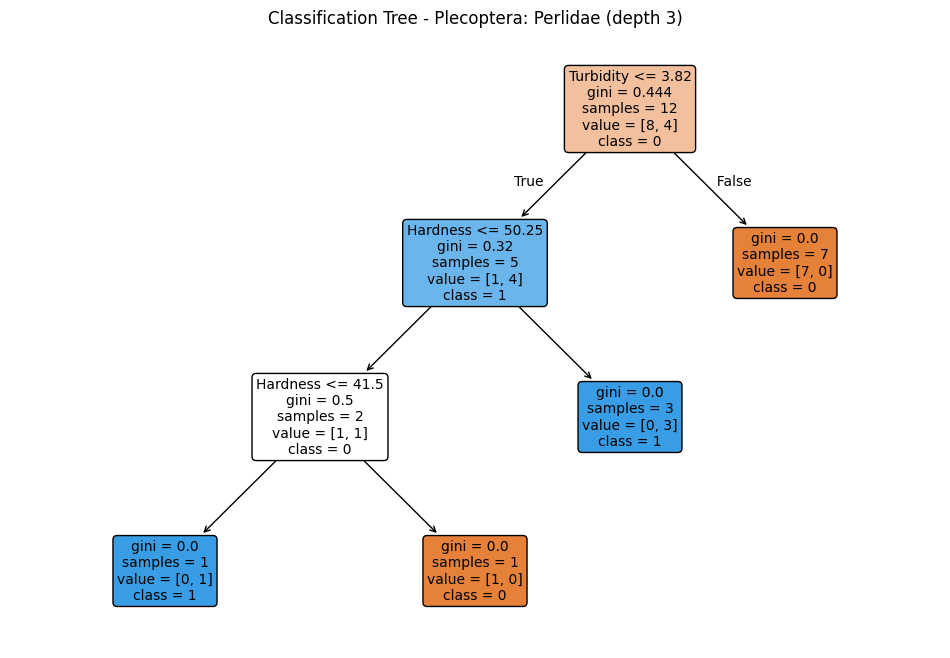

In [4]:
plt.figure(figsize=(12, 8))
plot_tree(clf_perlidae, feature_names=feature_names_en, class_names=['0', '1'],
          filled=True, rounded=True, impurity=True, fontsize=10)
plt.title("Classification Tree - Plecoptera: Perlidae (depth 3)")
plt.savefig("../../figures/tree_Perlidae.png", dpi=300, bbox_inches='tight')
plt.show()

### Helicopsychidae - tree with 7 predictors (depth 3)

In [5]:
X = df[feature_cols]
y = df['Trichoptera']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

clf_trich = DecisionTreeClassifier(max_depth=3, random_state=1)
cv = StratifiedKFold(n_splits=2, shuffle=True, random_state=1)

y_train_pred = cross_val_predict(clf_trich, X_train, y_train, cv=cv)
clf_trich.fit(X_train, y_train)
y_test_pred = clf_trich.predict(X_test)

print("Confusion matrix - calibration:")
print(confusion_matrix(y_train, y_train_pred))
print("\nClassification report - calibration:")
print(classification_report(y_train, y_train_pred))

print("Confusion matrix - validation:")
print(confusion_matrix(y_test, y_test_pred))
print("\nClassification report - validation:")
print(classification_report(y_test, y_test_pred))

Confusion matrix - calibration:
[[8 2]
 [1 1]]

Classification report - calibration:
              precision    recall  f1-score   support

           0       0.89      0.80      0.84        10
           1       0.33      0.50      0.40         2

    accuracy                           0.75        12
   macro avg       0.61      0.65      0.62        12
weighted avg       0.80      0.75      0.77        12

Confusion matrix - validation:
[[5 0]
 [1 0]]

Classification report - validation:
              precision    recall  f1-score   support

           0       0.83      1.00      0.91         5
           1       0.00      0.00      0.00         1

    accuracy                           0.83         6
   macro avg       0.42      0.50      0.45         6
weighted avg       0.69      0.83      0.76         6



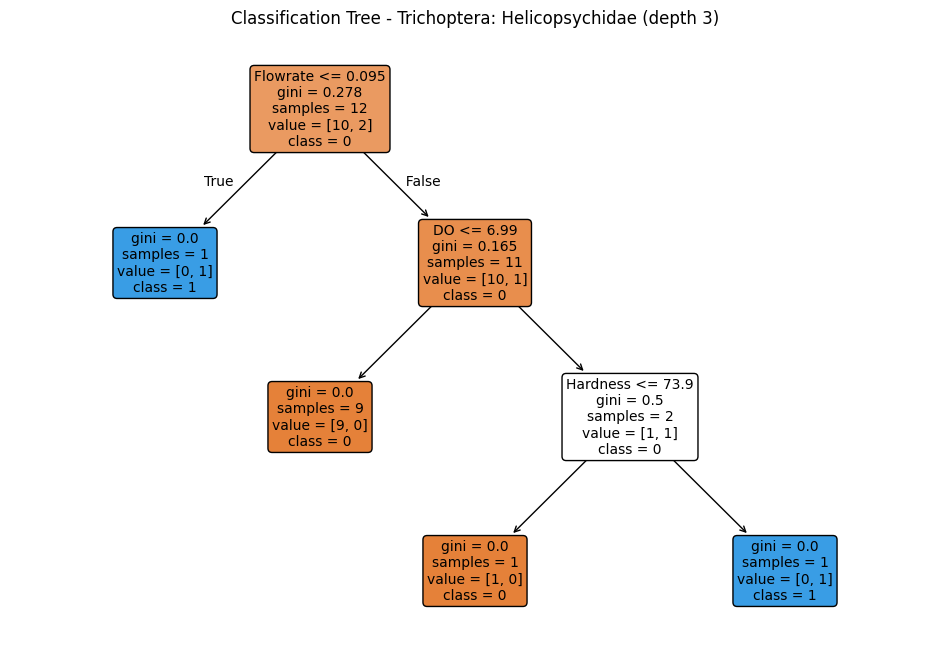

In [6]:
plt.figure(figsize=(12, 8))
plot_tree(clf_trich, feature_names=feature_names_en, class_names=['0', '1'],
          filled=True, rounded=True, impurity=True, fontsize=10)
plt.title("Classification Tree - Trichoptera: Helicopsychidae (depth 3)")
plt.savefig("../../figures/tree_Helicopsychidae.png", dpi=300, bbox_inches='tight')
plt.show()

### Perlidae - tree with DBO5 only (depth 2)

A simpler single-predictor tree, for comparison with the logistic model.

In [7]:
X = df[['DBO5']]
y = df['Perlidae']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

clf_dbo5 = DecisionTreeClassifier(max_depth=2, random_state=1)
cv = StratifiedKFold(n_splits=2, shuffle=True, random_state=1)

y_train_pred = cross_val_predict(clf_dbo5, X_train, y_train, cv=cv)
clf_dbo5.fit(X_train, y_train)
y_test_pred = clf_dbo5.predict(X_test)

print("Confusion matrix - calibration:")
print(confusion_matrix(y_train, y_train_pred))
print("\nClassification report - calibration:")
print(classification_report(y_train, y_train_pred))

print("Confusion matrix - validation:")
print(confusion_matrix(y_test, y_test_pred))
print("\nClassification report - validation:")
print(classification_report(y_test, y_test_pred))

Confusion matrix - calibration:
[[8 0]
 [4 0]]

Classification report - calibration:
              precision    recall  f1-score   support

           0       0.67      1.00      0.80         8
           1       0.00      0.00      0.00         4

    accuracy                           0.67        12
   macro avg       0.33      0.50      0.40        12
weighted avg       0.44      0.67      0.53        12

Confusion matrix - validation:
[[4 0]
 [2 0]]

Classification report - validation:
              precision    recall  f1-score   support

           0       0.67      1.00      0.80         4
           1       0.00      0.00      0.00         2

    accuracy                           0.67         6
   macro avg       0.33      0.50      0.40         6
weighted avg       0.44      0.67      0.53         6

